### Balanceo del dataset en crudo


In [ ]:
import os
import pandas as pd
import glob

def verificar_datos(dataset_base_path):
    dataset_dirs = sorted(glob.glob(os.path.join(dataset_base_path, 'dataset_*')))
    problemas = []

    for dataset_idx, dataset_dir in enumerate(dataset_dirs):
        labels_file = os.path.join(dataset_dir, 'labels.csv')
        if not os.path.exists(labels_file):
            print(f"Advertencia: No se encontró el archivo {labels_file}")
            continue

        labels_df = pd.read_csv(labels_file)
        for _, row in labels_df.iterrows():
            rgb_path = os.path.join(dataset_dir, 'imageRGB', row['image_rgb_name'])
            seg_path = os.path.join(dataset_dir, 'imageSEG', row['image_seg_name'])

            if not os.path.exists(rgb_path):
                problemas.append(f"Falta imagen RGB: {rgb_path}")

            if not os.path.exists(seg_path):
                problemas.append(f"Falta imagen SEG: {seg_path}")

    if problemas:
        print("Problemas encontrados:")
        for problema in problemas:
            print(problema)
    else:
        print("Todos los archivos están correctamente alineados.")

verificar_datos('/home/canveo/carla_ws/dataset_borracho//')


Todos los archivos están correctamente alineados.


In [2]:
# def balance_dataset(labels_df, target_column='steer', image_column='image', desired_count=6000, max_samples=5000, bins=30):
#     """
#     Balancea un dataset para que las distribuciones de 'steer' estén equilibradas.
#     Se conserva la correspondencia entre las imágenes y los valores de 'steer'.
#     """
#     resampled = pd.DataFrame()
#     bin_edges = np.linspace(labels_df[target_column].min(), labels_df[target_column].max(), bins + 1)  # Bins más detallados

#     for i in range(len(bin_edges) - 1):
#         lower, upper = bin_edges[i], bin_edges[i + 1]
#         # Filtrar las filas que caen en el bin actual
#         part_df = labels_df[(labels_df[target_column] >= lower) & (labels_df[target_column] < upper)]

#         if part_df.shape[0] > 0:
#             # Si hay más muestras que el máximo permitido, submuestrea
#             if part_df.shape[0] > max_samples:
#                 part_df = part_df.sample(max_samples, random_state=42)

#             # Repetir para alcanzar el número deseado
#             repeat_factor = max(1, desired_count // part_df.shape[0])
#             part_df_repeated = pd.concat([part_df] * repeat_factor, ignore_index=True)

#             # Agregar muestras aleatorias adicionales si es necesario
#             remaining_samples = desired_count - part_df_repeated.shape[0]
#             if remaining_samples > 0:
#                 part_df_remaining = part_df.sample(remaining_samples, replace=True, random_state=1)
#                 part_df_repeated = pd.concat([part_df_repeated, part_df_remaining], ignore_index=True)

#             # Concatenar las muestras al DataFrame resampleado
#             resampled = pd.concat([resampled, part_df_repeated], ignore_index=True)

#     return resampled

In [ ]:

def create_combined_dataset(dataset_base_path):
    combined_data = []
    dataset_dirs = sorted(glob.glob(os.path.join(dataset_base_path, 'dataset_*')))

    for dataset_idx, dataset_dir in enumerate(dataset_dirs):
        labels_file = os.path.join(dataset_dir, 'labels.csv')
        
        if os.path.exists(labels_file):
            labels_df = pd.read_csv(labels_file)
            if not labels_df.empty:
                
                labels_df['rgb_path'] = labels_df['image_rgb_name'].apply(
                    lambda name: os.path.join(dataset_dir, 'imageRGB', name)
                )
                labels_df['seg_path'] = labels_df['image_seg_name'].apply(
                    lambda name: os.path.join(dataset_dir, 'imageSEG', name)
                )

                
                labels_df = labels_df[['rgb_path', 'seg_path', 'curvarade', 'steer', 'throttle', 'brake']]

                combined_data.append(labels_df)
            else:
                print(f"Advertencia: El archivo {labels_file} está vacío.")
        else:
            print(f"Advertencia: No se encontró el archivo {labels_file}")

    if combined_data:
        
        combined_df = pd.concat(combined_data, ignore_index=True)

        
        combined_df.to_csv('combined_data.csv', index=False)
        print(f"Total de filas combinadas: {len(combined_df)}")
        print(combined_df.head())  
    else:
        print("Error: No se encontraron datos para combinar.")
        raise ValueError("No objects to concatenate")



dataset_base_path = '/home/canveo/carla_ws/dataset_borracho//'
create_combined_dataset(dataset_base_path)

Total de filas combinadas: 65545
                                            rgb_path  \
0  /home/canveo/carla_ws/dataset_borracho/dataset...   
1  /home/canveo/carla_ws/dataset_borracho/dataset...   
2  /home/canveo/carla_ws/dataset_borracho/dataset...   
3  /home/canveo/carla_ws/dataset_borracho/dataset...   
4  /home/canveo/carla_ws/dataset_borracho/dataset...   

                                            seg_path curvarade     steer  \
0  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta -0.800000   
1  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta -0.800000   
2  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta  0.008920   
3  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta  0.008920   
4  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta  0.006374   

   throttle  brake  
0      0.10    0.0  
1      0.10    0.0  
2      0.85    0.0  
3      0.85    0.0  
4      0.85    0.0  


### Modelo PilotNet

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

def pilotnet(img_shape, learning_rate):
    model = Sequential()
    model.add(tf.keras.layers.InputLayer(shape=img_shape))  
    model.add(BatchNormalization(epsilon=0.001, axis=-1))
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation="relu", padding='valid'))
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation="relu", padding='valid'))
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation="relu", padding='valid'))
    model.add(Conv2D(64, (3, 3), strides=(1, 1), activation="relu", padding='valid'))
    model.add(Conv2D(64, (3, 3), strides=(1, 1), activation="relu", padding='valid'))
    
    model.add(Flatten())
    model.add(Dense(1164, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(100, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(50, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(10, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(1))
    
    # Configurar el optimizador
    adam = Adam(learning_rate=learning_rate)
    model.compile(optimizer=adam, loss="mse", metrics=['mse', 'mae'])
    return model


2024-11-12 20:58:44.472815: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-12 20:58:44.652199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-12 20:58:44.740597: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-12 20:58:44.764233: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-12 20:58:44.903084: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
import os
import cv2
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

def process_image(image_info):
    seg_path, steer_value = image_info  
    full_seg_path = seg_path
    
    
    if not os.path.isfile(full_seg_path):
        raise FileNotFoundError(f"La imagen segmentada {full_seg_path} no se encuentra.")
    
    
    image_seg = cv2.imread(full_seg_path)
    if image_seg is None:
        raise ValueError(f"Error al leer la imagen segmentada {full_seg_path}.")
    
    
    calzada_color = [128, 64, 128]
    mask = cv2.inRange(image_seg, np.array(calzada_color), np.array(calzada_color))
    
    
    image_seg_masked = np.zeros_like(image_seg)
    image_seg_masked[mask > 0] = [255, 255, 255]  
    
    
    image_seg_rgb = cv2.resize(image_seg_masked[200:-1, :], (200, 66))
    
    
    image_seg_rgb = cv2.cvtColor(image_seg_rgb, cv2.COLOR_BGR2GRAY)
    image_seg_rgb = cv2.merge([image_seg_rgb, image_seg_rgb, image_seg_rgb])
    
    
    return image_seg_rgb, steer_value

def get_images_array(df, max_workers=4):
    required_columns = ['seg_path', 'steer']
    for column in required_columns:
        if column not in df.columns:
            raise ValueError(f"La columna '{column}' no se encuentra en el DataFrame.")
    
    steering_values = df['steer'].to_numpy()
    seg_paths = df['seg_path'].tolist()
    
    if len(seg_paths) != len(steering_values):
        raise ValueError("El número de nombres de imágenes no coincide con el número de valores de dirección.")
    
    image_info_list = [(seg_paths[i], steering_values[i]) for i in range(len(seg_paths))]

    images = []
    labels = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_image = {executor.submit(process_image, info): info for info in image_info_list}
        
        
        for future in tqdm(as_completed(future_to_image), total=len(image_info_list), desc="Procesando imágenes"):
            try:
                processed_image, label = future.result()
                images.append(processed_image)
                labels.append(label)
            except Exception as exc:
                print(f'Error al procesar la imagen: {exc}')

    return np.array(images), np.array(labels)


In [6]:
import tensorflow as tf
import numpy as np
import albumentations as A

# Definir las transformaciones con albumentations
train_transform = A.Compose([
    A.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2, hue=0.1, p=0.4),
    A.RandomBrightnessContrast(p=0.4),
    A.RandomGamma(gamma_limit=(80, 150), p=0.4),
    A.HueSaturationValue(
        hue_shift_limit=20,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=0.4
    ),
    A.FancyPCA(alpha=0.1, p=0.4),
    A.GaussianBlur(blur_limit=(1, 3), p=0.4),
])

val_transform = A.Compose([])  # Dejar sin transformaciones para validación

class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, x_set, y_set, transform=None, batch_size=32, shuffle=True):
        self.x = x_set
        self.y = y_set
        self.transform = transform
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.x))
        self.on_epoch_end()

    def __len__(self):
        # Número total de batches
        return len(self.x) // self.batch_size

    def on_epoch_end(self):
        # Barajar los datos al final de cada época
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        # Obtener un batch de datos
        indices = self.indices[idx * self.batch_size: (idx + 1) * self.batch_size]
        batch_x = [self.x[i] for i in indices]
        batch_y = [self.y[i] for i in indices]

        # Transformar y preprocesar cada imagen en el batch
        batch_x_transformed = []
        for img in batch_x:
            # Aplicar transformaciones de albumentations si están definidas
            if self.transform:
                transformed = self.transform(image=img)
                img_transformed = transformed["image"]
            else:
                img_transformed = img

            # Normalizar y ajustar el formato a TensorFlow (H, W, C)
            img_transformed = tf.convert_to_tensor(img_transformed, dtype=tf.float32)
            batch_x_transformed.append(img_transformed)

        batch_x_transformed = tf.stack(batch_x_transformed)  # Combinar imágenes en un solo tensor
        batch_y = tf.convert_to_tensor(batch_y, dtype=tf.float32)

        return batch_x_transformed, batch_y


In [ ]:
dataset_base_path = '/home/canveo/carla_ws/dataset_borracho/'

# dataset combinado
combined_data = create_combined_dataset(dataset_base_path)

# labels_df = combined_data[['steer']]
labels_df = pd.read_csv('combined_data.csv')
labels_df = labels_df[labels_df['curvarade'] == 'Curva']

Total de filas combinadas: 65545
                                            rgb_path  \
0  /home/canveo/carla_ws/dataset_borracho/dataset...   
1  /home/canveo/carla_ws/dataset_borracho/dataset...   
2  /home/canveo/carla_ws/dataset_borracho/dataset...   
3  /home/canveo/carla_ws/dataset_borracho/dataset...   
4  /home/canveo/carla_ws/dataset_borracho/dataset...   

                                            seg_path curvarade     steer  \
0  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta -0.800000   
1  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta -0.800000   
2  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta  0.008920   
3  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta  0.008920   
4  /home/canveo/carla_ws/dataset_borracho/dataset...     Recta  0.006374   

   throttle  brake  
0      0.10    0.0  
1      0.10    0.0  
2      0.85    0.0  
3      0.85    0.0  
4      0.85    0.0  


In [8]:
labels_df

,rgb_path,seg_path,curvarade,steer,throttle,brake
77,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,0.000000,0.060693,0.0
78,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,0.000000,0.060693,0.0
79,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.150000,0.850000,0.0
80,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.300000,0.850000,0.0
81,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.444598,0.850000,0.0
...,...,...,...,...,...,...
65540,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
65541,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
65542,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
65543,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0


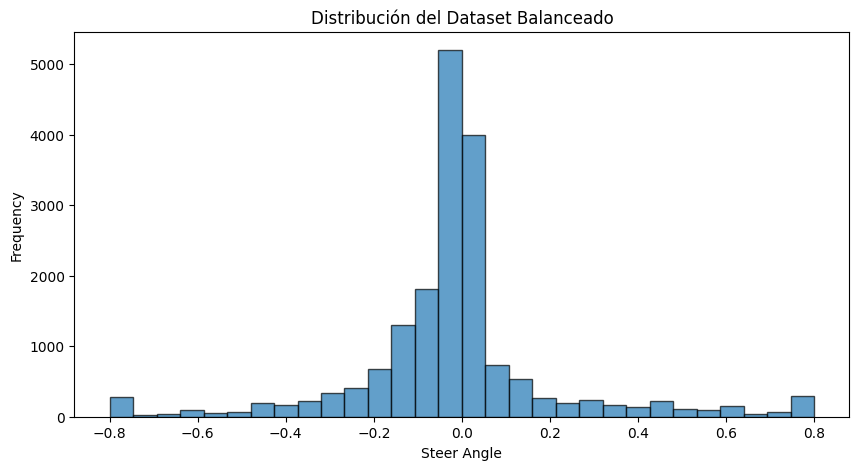

In [9]:
import matplotlib.pyplot as plt

# balanced_data = balance_dataset(labels_df, target_column='steer', desired_count=3000, max_samples=2000, bins=50)

# Graficar la distribución del dataset balanceado
plt.figure(figsize=(10, 5))
plt.hist(labels_df['steer'], bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Steer Angle')
plt.ylabel('Frequency')
plt.title('Distribución del Dataset Balanceado')
plt.show()

(-0.16, 0.0]       7445
(0.0, 0.16]        3113
(-0.32, -0.16]     1416
(0.16, 0.32]        702
(-0.48, -0.32]      576
(0.32, 0.48]        533
(0.64, 0.8]         411
(0.48, 0.64]        349
(-0.803, -0.64]     326
(-0.64, -0.48]      214
Name: count, dtype: int64


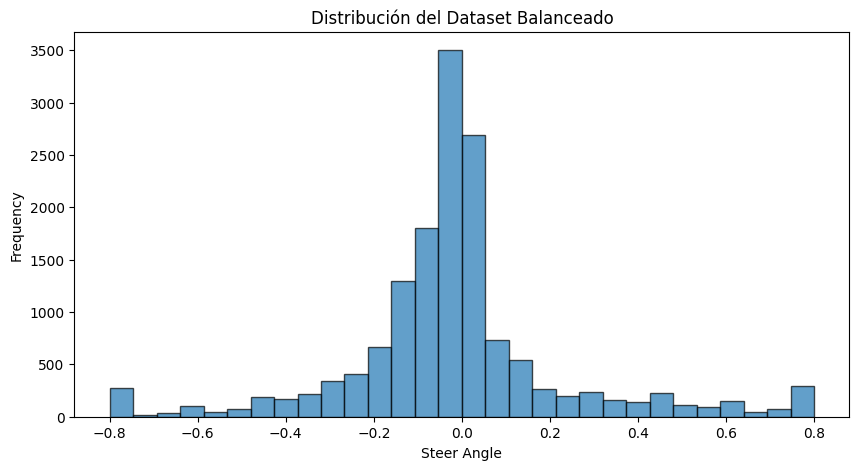

In [ ]:
import pandas as pd

# labels_df = pd.read_csv("ruta_a_tu_archivo.csv")  

# rango de steer para considerar como "recta"
steer_min = -0.05
steer_max = 0.05

# Filtrar las filas que están en el rango de steer cerca de cero (rectas)
rectas_df = labels_df[(labels_df['steer'] >= steer_min) & (labels_df['steer'] <= steer_max)]

# Filtrar las filas fuera del rango (curvas y otros)
otras_df = labels_df[(labels_df['steer'] < steer_min) | (labels_df['steer'] > steer_max)]

# Muestrear aleatoriamente hasta 6000 filas del conjunto de rectas
rectas_sampled = rectas_df.sample(n=6000, random_state=42) if len(rectas_df) > 6000 else rectas_df

# Concatenar el dataset balanceado
labels_df_balanced = pd.concat([rectas_sampled, otras_df], ignore_index=True)

# Verificar la distribución después del balanceo
print(labels_df_balanced['steer'].value_counts(bins=10))  # Puedes ajustar el número de bins según lo necesario

# Guardar el nuevo dataset si es necesario
# labels_df_balanced.to_csv("ruta_a_tu_nuevo_archivo.csv", index=False)

# Graficar la distribución del dataset balanceado
plt.figure(figsize=(10, 5))
plt.hist(labels_df_balanced['steer'], bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Steer Angle')
plt.ylabel('Frequency')
plt.title('Distribución del Dataset Balanceado')
plt.show()


Distribución de muestras por rango de 'steer':
(0.6, 0.68]        8000
(-0.76, -0.68]     7998
(-0.6, -0.52]      7980
(-0.44, -0.36]     7953
(0.36, 0.44]       7942
(0.52, 0.6]        7938
(0.68, 0.76]       7938
(-0.68, -0.6]      7935
(0.76, 0.84]       7904
(-0.28, -0.2]      7904
(0.2, 0.28]        7884
(-0.84, -0.76]     7874
(-0.52, -0.44]     7844
(0.44, 0.52]       7801
(0.28, 0.36]       7776
(0.12, 0.2]        7644
(-0.36, -0.28]     7582
(-0.2, -0.12]      7380
(-0.04, 0.04]      5465
(-0.12, -0.04]     5368
(0.04, 0.12]       1054
(0.84, 0.92]          0
(-1.001, -0.92]       0
(-0.92, -0.84]        0
(0.92, 1.0]           0
Name: count, dtype: int64


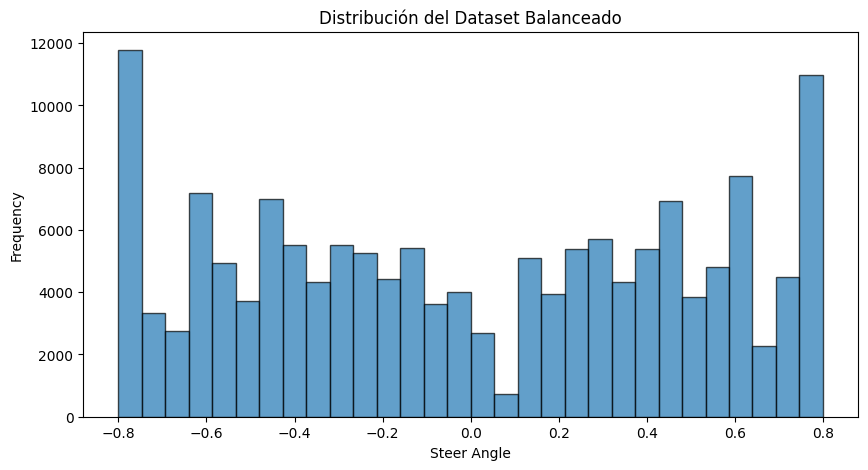

In [11]:
import pandas as pd
import numpy as np

# Parámetros
desired_count = 8000
resampled = pd.DataFrame()

# Iterar sobre los rangos de steer en incrementos de 0.08
for small_r in np.arange(-1.0, 1.0, 0.08):
    part_df = labels_df_balanced.loc[(labels_df_balanced['steer'] >= small_r) & (labels_df_balanced['steer'] < small_r + 0.08)]
    
    # Ajustar el desired_count para los valores cercanos a cero
    if -0.04 <= small_r < 0.08:
        desired_count_local = 1000
    else:
        desired_count_local = desired_count

    # Remuestrear si el tamaño de las muestras es menor al deseado
    if part_df.shape[0] > 0 and part_df.shape[0] < desired_count_local:
        # Calcular el factor de repetición necesario
        repeat_factor = max(1, desired_count_local // part_df.shape[0])
        part_df_repeated = pd.concat([part_df] * repeat_factor, ignore_index=True)
        
        # Agregar muestras adicionales si es necesario para alcanzar el desired_count_local
        # remaining_samples = desired_count_local - part_df_repeated.shape[0]
        # if remaining_samples > 0:
        #     part_df_remaining = part_df.sample(remaining_samples, replace=True, random_state=1)
        #     part_df_repeated = pd.concat([part_df_repeated, part_df_remaining], ignore_index=True)
        
        # Agregar al dataframe resampled
        resampled = pd.concat([resampled, part_df_repeated], ignore_index=True)
    else:
        # Si ya tiene suficientes muestras, agregar la parte original
        resampled = pd.concat([resampled, part_df], ignore_index=True)

# Verificar el resultado final
print("Distribución de muestras por rango de 'steer':")
print(resampled['steer'].value_counts(bins=np.arange(-1.0, 1.08, 0.08)))


# Verificar la nueva distribución del dataset balanceado
import matplotlib.pyplot as plt

# Graficar la distribución del dataset balanceado
plt.figure(figsize=(10, 5))
plt.hist(resampled['steer'], bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Steer Angle')
plt.ylabel('Frequency')
plt.title('Distribución del Dataset Balanceado')
plt.show()


# Opcionalmente, guardar el nuevo dataset balanceado
# labels_df_aumentado.to_csv("ruta_a_tu_dataset_aumentado.csv", index=False)
# Graficar la distribución del dataset balanceado


In [12]:
resampled

,rgb_path,seg_path,curvarade,steer,throttle,brake
0,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
1,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
2,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
3,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.800000,0.850000,0.0
4,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,-0.794222,0.476648,0.0
...,...,...,...,...,...,...
153159,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,0.800000,0.850000,0.0
153160,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,0.800000,0.850000,0.0
153161,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,0.800000,0.850000,0.0
153162,/home/canveo/carla_ws/dataset_borracho/dataset...,/home/canveo/carla_ws/dataset_borracho/dataset...,Curva,0.800000,0.850000,0.0


In [13]:
# Obtener todas las imágenes y etiquetas
all_images, all_labels = get_images_array(resampled)

Procesando imágenes: 100%|███████████████████████████████████████████| 153164/153164 [03:25<00:00, 744.19it/s]


In [14]:
len(all_images)

153164

In [15]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Dividir en conjunto de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.2, random_state=42)

# Crear los datasets utilizando DataGenerator
train_dataset = DataGenerator(X_train, y_train, transform=train_transform, batch_size=64, shuffle=True)
val_dataset = DataGenerator(X_val, y_val, transform=val_transform, batch_size=64, shuffle=False)

# # Convertir los generadores a `tf.data.Dataset` para TensorFlow
# train_dataset = tf.data.Dataset.from_generator(
#     lambda: train_generator,
#     output_signature=(
#         tf.TensorSpec(shape=(None, 66, 200, 3), dtype=tf.float32),  # Cambia el shape si es diferente
#         tf.TensorSpec(shape=(None,), dtype=tf.float32)
#     )
# )

# val_dataset = tf.data.Dataset.from_generator(
#     lambda: val_generator,
#     output_signature=(
#         tf.TensorSpec(shape=(None, 66, 200, 3), dtype=tf.float32),  # Cambia el shape si es diferente
#         tf.TensorSpec(shape=(None,), dtype=tf.float32)
#     )
# )

# # Prefetch para optimizar
# train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
# val_dataset = val_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)


In [16]:
import os
import json
import datetime
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

# Definir el callback personalizado para registro de entrenamiento
class TrainingLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_dir, params):
        super(TrainingLogger, self).__init__()
        self.log_dir = log_dir
        self.params = params

    def on_train_begin(self, logs=None):
        # Guardar los parámetros iniciales de entrenamiento en un archivo JSON
        with open(os.path.join(self.log_dir, 'training_params.json'), 'w') as f:
            json.dump(self.params, f)

    def on_epoch_end(self, epoch, logs=None):
        # Guardar métricas de cada época en un archivo JSON
        logs = logs or {}
        with open(os.path.join(self.log_dir, f'epoch_{epoch}_logs.json'), 'w') as f:
            json.dump(logs, f)

# Configurar el directorio base para los registros de experimentos
base_log_dir = "./logs"
condition = "your_condition"  # Cambia esto según el nombre o condiciones del experimento
experiment_name = f"{condition}_experiment_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
experiment_dir = os.path.join(base_log_dir, experiment_name)

# Asegurar que el directorio del experimento exista
os.makedirs(experiment_dir, exist_ok=True)

# Parámetros de entrenamiento
training_params = {
    "batch_size": 32,
    "learning_rate": 0.0001,
    "epochs": 100,
    "img_shape": (66, 200, 3),
}


model = pilotnet(training_params['img_shape'], training_params['learning_rate'])

# Guardar los parámetros de entrenamiento iniciales
with open(os.path.join(experiment_dir, 'params.json'), 'w') as f:
    json.dump(training_params, f)

# Configurar callbacks
training_logger_callback = TrainingLogger(experiment_dir, training_params)
tb = TensorBoard(log_dir=experiment_dir, histogram_freq=1)
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar el modelo
history = model.fit(
    train_dataset,
    epochs=training_params["epochs"],
    validation_data=val_dataset,
    callbacks=[training_logger_callback, tb, es]
)

I0000 00:00:1731463511.994752    3752 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731463512.123701    3752 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731463512.124112    3752 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731463512.128308    3752 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Epoch 1/100


/home/canveo/venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1731463515.096526    5665 service.cc:146] XLA service 0x75f0d0028050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731463515.096572    5665 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2024-11-12 21:05:15.164385: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-12 21:05:15.404809: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8902


   3/1914 ━━━━━━━━━━━━━━━━━━━━ 1:22 43ms/step - loss: 0.2623 - mae: 0.4484 - mse: 0.2623 

I0000 00:00:1731463520.068618    5665 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1913/1914 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0836 - mae: 0.2123 - mse: 0.0836

2024-11-12 21:08:42.621005: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_99', 240 bytes spill stores, 240 bytes spill loads



1914/1914 ━━━━━━━━━━━━━━━━━━━━ 221s 112ms/step - loss: 0.0836 - mae: 0.2123 - mse: 0.0836 - val_loss: 0.0124 - val_mae: 0.0797 - val_mse: 0.0124
Epoch 2/100
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 210s 109ms/step - loss: 0.0231 - mae: 0.1114 - mse: 0.0231 - val_loss: 0.0058 - val_mae: 0.0533 - val_mse: 0.0058
Epoch 3/100
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 227s 119ms/step - loss: 0.0162 - mae: 0.0918 - mse: 0.0162 - val_loss: 0.0043 - val_mae: 0.0457 - val_mse: 0.0043
Epoch 4/100
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 220s 115ms/step - loss: 0.0134 - mae: 0.0821 - mse: 0.0134 - val_loss: 0.0040 - val_mae: 0.0450 - val_mse: 0.0040
Epoch 5/100
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 219s 114ms/step - loss: 0.0115 - mae: 0.0766 - mse: 0.0115 - val_loss: 0.0033 - val_mae: 0.0412 - val_mse: 0.0033
Epoch 6/100
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 224s 117ms/step - loss: 0.0103 - mae: 0.0720 - mse: 0.0103 - val_loss: 0.0026 - val_mae: 0.0361 - val_mse: 0.0026
Epoch 7/100
1914/1914 ━━━━━━━━━━━━━━━━━━━━ 223s 116ms/step - loss: 0.0

In [23]:
model.save("modelo_pilotnet_curva.h5")
model.save("modelo_pilotnet_curva.keras")

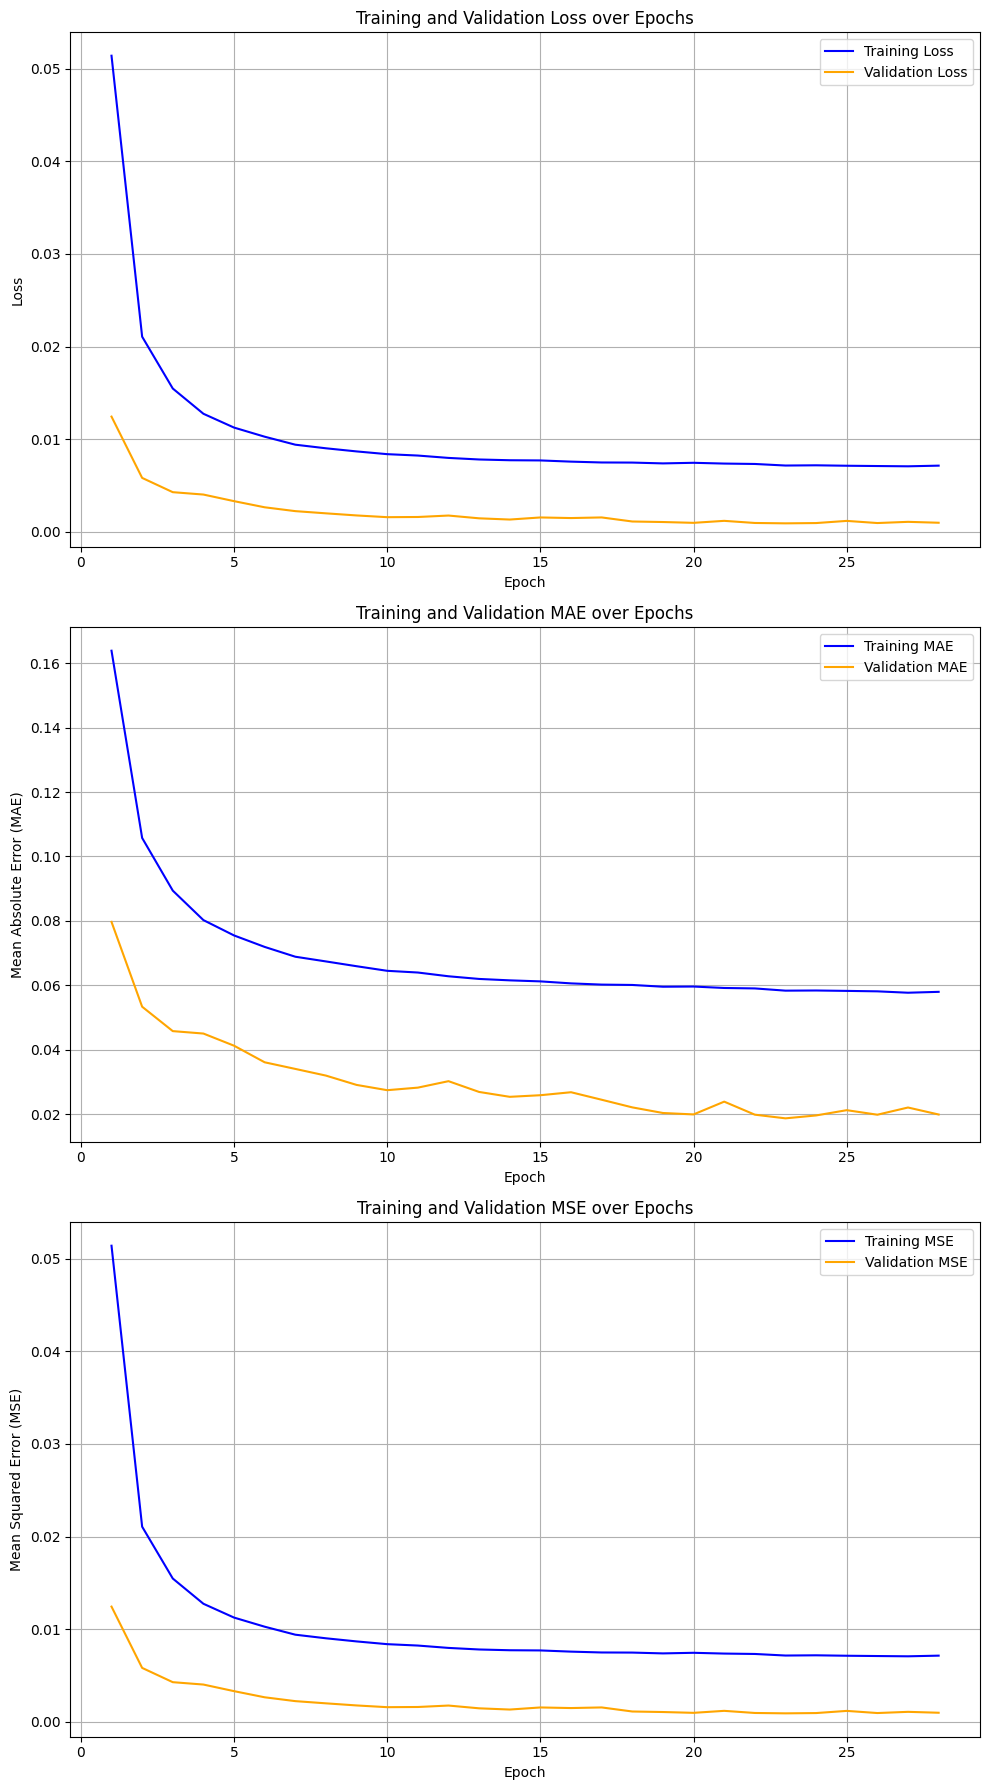

In [24]:
import matplotlib.pyplot as plt

# Obtener datos del historial de entrenamiento
epochs = range(1, len(history.history['loss']) + 1)
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mae = history.history['mae']
val_mae = history.history['val_mae']
train_mse = history.history['mse']
val_mse = history.history['val_mse']

# Crear una figura y subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Gráfico de Loss
axes[0].plot(epochs, train_loss, label="Training Loss", color="blue")
axes[0].plot(epochs, val_loss, label="Validation Loss", color="orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss over Epochs")
axes[0].legend()
axes[0].grid(True)

# Gráfico de MAE
axes[1].plot(epochs, train_mae, label="Training MAE", color="blue")
axes[1].plot(epochs, val_mae, label="Validation MAE", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Absolute Error (MAE)")
axes[1].set_title("Training and Validation MAE over Epochs")
axes[1].legend()
axes[1].grid(True)

# Gráfico de MSE
axes[2].plot(epochs, train_mse, label="Training MSE", color="blue")
axes[2].plot(epochs, val_mse, label="Validation MSE", color="orange")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean Squared Error (MSE)")
axes[2].set_title("Training and Validation MSE over Epochs")
axes[2].legend()
axes[2].grid(True)

# Ajustar el espacio entre los gráficos
plt.tight_layout()
plt.savefig("training_results.png")  # Guarda el gráfico en un archivo
plt.show()  # Muestra el gráfico en pantalla


958/958 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step
(30633, 1)


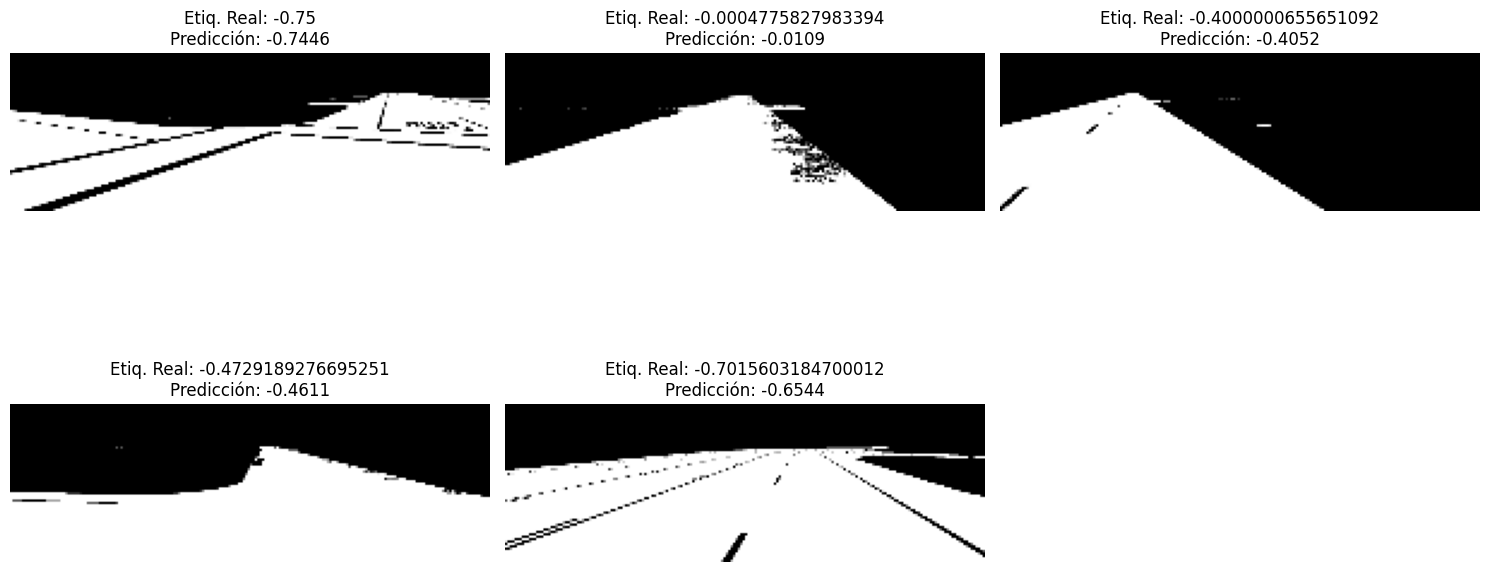

In [25]:
import random
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Realizar predicciones sobre el conjunto de validación
predictions = model.predict(X_val)

# Verificar la forma de las predicciones
print(predictions.shape)  # Debe coincidir con la cantidad de muestras en X_val

# Seleccionar aleatoriamente 5 muestras para visualizar
sample_indices = random.sample(range(len(X_val)), 5)

# Crear la figura para mostrar las imágenes y las predicciones
plt.figure(figsize=(15, 8))
for i, idx in enumerate(sample_indices, 1):
    plt.subplot(2, 3, i)
    
    # Mostrar la imagen
    plt.imshow(X_val[idx])
    plt.title(f'Etiq. Real: {y_val[idx]}\nPredicción: {predictions[idx][0]:.4f}')
    plt.axis('off')

plt.tight_layout()

# Guardar la gráfica con un nombre único basado en la fecha y hora actuales
os.makedirs("images", exist_ok=True)  # Crear el directorio si no existe
path_name = os.path.join('images/', str(datetime.now().strftime("%Y-%m-%d_%H-%M-%S")) + "_pilotnet_prediccion.png")
plt.savefig(path_name)
plt.show()


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


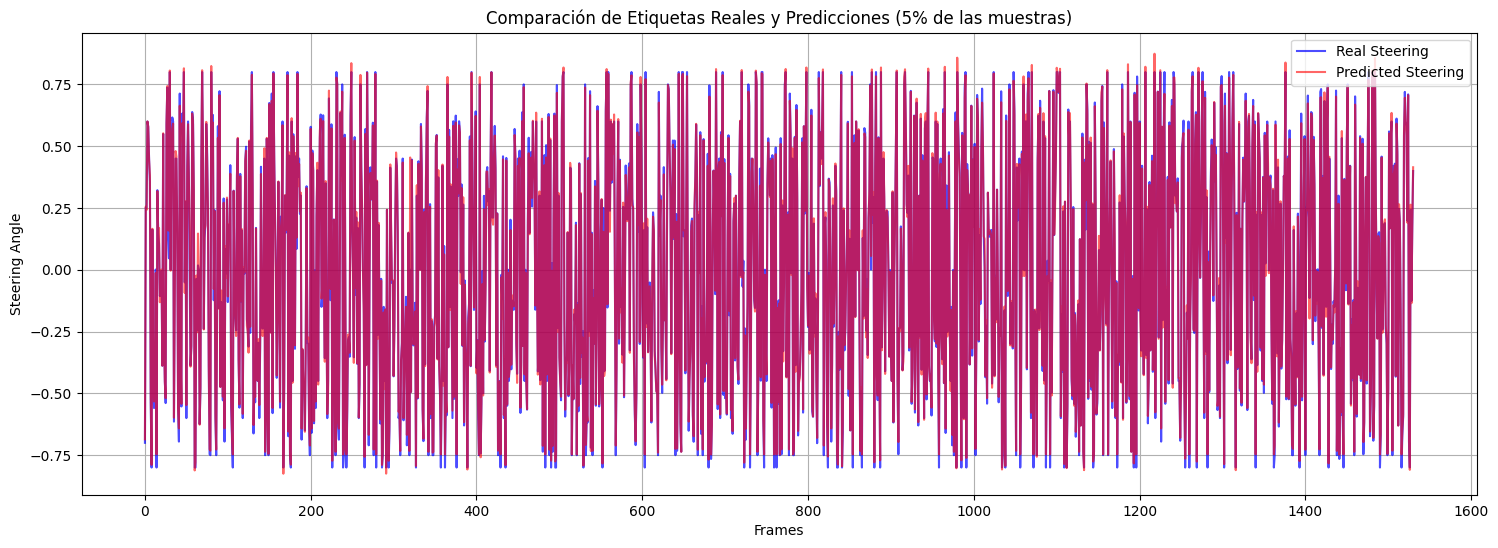

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Definir el porcentaje de muestras que quieres usar
percentage = 0.05  # Por ejemplo, 20%

# Calcular el número de muestras en función del porcentaje
num_samples = int(len(X_val) * percentage)

# Seleccionar índices aleatorios de las muestras
sample_indices = random.sample(range(len(X_val)), num_samples)

# Crear submuestras de X_val y y_val utilizando los índices seleccionados
X_val_sample = X_val[sample_indices]
y_val_sample = np.array(y_val)[sample_indices]

# Realizar predicciones en las submuestras seleccionadas
predicted_steering_sample = model.predict(X_val_sample)

# Asegurarse de que `y_val_sample` y `predicted_steering_sample` sean arrays de numpy
real_steering_sample = np.array(y_val_sample)  # Las etiquetas reales de la muestra
predicted_steering_sample = np.array(predicted_steering_sample).squeeze()  # Predicciones de la muestra

# Crear el gráfico de comparación
plt.figure(figsize=(18, 6))
plt.plot(real_steering_sample, label="Real Steering", color="blue", alpha=0.7)
plt.plot(predicted_steering_sample, label="Predicted Steering", color="red", alpha=0.6)
plt.xlabel("Frames")
plt.ylabel("Steering Angle")
plt.title(f"Comparación de Etiquetas Reales y Predicciones ({int(percentage*100)}% de las muestras)")
plt.legend()
plt.grid(True)
plt.show()


In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError

# Cargar el modelo, especificando las funciones de pérdida y métricas
modelo_cargado = load_model("modelo_pilotnet_curva.h5", custom_objects={
    "mse": MeanSquaredError(),
    "mae": MeanAbsoluteError(),
})

In [28]:
# Evaluar el modelo en el conjunto de validación o en cualquier conjunto de datos
# Esto asegurará que los métricos se construyan
loss, mae, mse = modelo_cargado.evaluate(X_val, y_val, verbose=1)
print("Loss:", loss, "MAE:", mae, "MSE:", mse)


958/958 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.8701e-04 - mean_absolute_error: 0.0185 - mean_squared_error: 8.5740e-04
Loss: 0.0008570515783503652 MAE: 0.0009103280026465654 MSE: 0.01865137740969658


In [29]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError

# Volver a compilar el modelo después de cargarlo
modelo_cargado.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=MeanSquaredError(),
    metrics=[MeanSquaredError(), MeanAbsoluteError()]
)
